In [ ]:
from langgraph.graph import StateGraph, START,END 
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [ ]:
# Create state structure using TypedDict

class LLMstate(TypedDict):
    topic: str
    summary: str
    quiz: str

In [ ]:
# Creating graph with LLMstate

graph = StateGraph(LLMstate)

In [ ]:
# Node 1: Summary Generator 

def summary_generator(state: LLMstate) -> LLMstate:
    
    topic = state["topic"]

    prompt = f"Write a summary on topic: {topic}"

    summary = llm.invoke(prompt)

    state["summary"] = summary

    return state

In [ ]:
# Node 2: Quiz Generator 

def quiz_generator(state: LLMstate) -> LLMstate:

    topic = state["topic"]
    summary = state["summary"]

    prompt = f"make a 5 question Quiz on topic: {topic} using summary: {summary}"

    quiz = llm.invoke(prompt)

    state["quiz"] = quiz

    return state

In [ ]:
# Add Nodes 

graph.add_node("summary_generator",summary_generator)
graph.add_node("quiz_generator",quiz_generator)

In [ ]:
# Add Edges

graph.add_edge(START,"summary_generator")
graph.add_edge("summary_generator","quiz_generator")
graph.add_edge("quiz_generator",END)

In [ ]:
# Compile graph into workflow 

workflow = graph.compile()

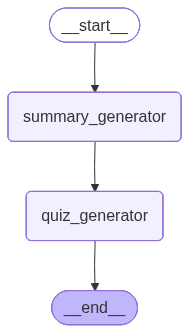

In [ ]:
# Graph Visual 

workflow

In [ ]:
# Define Start State with input 

start_state = {"topic":"interstellar movie"}

# Invoke Graph using initial state and store into final_state

final_state = workflow.invoke(start_state)


In [ ]:
# Getting Output

print(final_state["summary"].content)
print(final_state["quiz"].content)

*Interstellar* is a science fiction epic that follows a team of astronauts on a desperate mission to save humanity from extinction.

Set in a dystopian future where Earth is slowly becoming uninhabitable due to a global blight and dust storms, the film centers on Cooper (Matthew McConaughey), a former pilot turned farmer, struggling to provide for his children, especially his bright daughter Murph. A series of mysterious gravitational anomalies lead Cooper to a secret NASA facility, where he reunites with his former professor, Dr. Brand (Michael Caine).

Dr. Brand reveals that humanity's only hope lies in the "Lazarus Mission," which sent twelve astronauts through a newly discovered wormhole near Saturn to assess potentially habitable planets in another galaxy. With time running out for Earth, Cooper is recruited to pilot the Endurance spacecraft, accompanied by Dr. Brand's daughter, Amelia Brand (Anne Hathaway), and a small crew.

The mission is fraught with the dangers of deep space 